<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 2 &middot; XGBoost & Random Forest</h4>
<h1 align="center">XGBoost &mdash; Pima Indians Diabetes</h1>
<p align="center"><i>From CART to gradient boosting to XGBoost: theory, training, and evaluation</i></p>

---

## Overview

This is the capstone notebook of the XGBoost session. We cover, **in order**:

1. A 60-second recap of CART and Random Forest.
2. Gradient boosting from first principles.
3. What makes XGBoost specifically different from plain CART/GBM (the gain formula).
4. XGBoost's native handling of missing values.
5. Overfitting vs. underfitting in boosting, and the regularization knobs that control it.
6. Why XGBoost remains a "need of the hour" tool.
7. Training and evaluating an `XGBClassifier` on our processed diabetes data.
8. A hyperparameter reference, tied directly back to the gain formula and objective function.
9. The wider landscape: loss functions boosting can plug in, contrasted with Random Forest's
   fixed objective.

Let's load the processed splits produced by `02_data_processing.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

train_df = pd.read_csv("data/diabetes_processed_train.csv")
test_df = pd.read_csv("data/diabetes_processed_test.csv")

X_train_full = train_df.drop(columns=["Outcome"])
y_train_full = train_df["Outcome"]
X_test = test_df.drop(columns=["Outcome"])
y_test = test_df["Outcome"]

print("Train:", X_train_full.shape, " Test:", X_test.shape)

# A validation carve-out from the TRAINING split only, used for early stopping and
# hyperparameter tuning below. The test set stays fully held out until the final
# evaluation section.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)
print("Sub-train:", X_tr.shape, " Validation:", X_val.shape)

Train: (614, 10)  Test: (154, 10)
Sub-train: (491, 10)  Validation: (123, 10)


## 1. Sixty-second recap: CART and Random Forest

*(If you've already been through `03_random_forest/03_train_test_eval.ipynb`, skip ahead --
this is a refresher, not a full treatment.)*

A **CART** (Classification and Regression Tree) grows by repeatedly picking the feature and
threshold that best separates the classes in a node, using an **impurity** measure -- most
commonly **Gini impurity**,

$$Gini = 1 - \sum_{c} p_c^2,$$

or **entropy**,

$$H = -\sum_{c} p_c \log_2 p_c,$$

where $p_c$ is the proportion of class $c$ in the node. A split is chosen to maximize the
**information gain**: the impurity of the parent node minus the weighted impurity of the two
children. A single tree, grown deep, fits the training data very well but tends to have high
**variance** -- small changes in the training data can produce a very different tree.

**Random Forest** tackles that variance by growing many such trees, each on a bootstrap
resample of the data and a random subset of features per split, and then **averaging** their
predictions (majority vote for classification). Averaging many noisy-but-roughly-unbiased
trees cancels out much of the individual variance, without touching bias much -- this is
why Random Forest is comparatively resistant to overfitting as you add more trees.

**Gradient boosting, which XGBoost implements, takes the opposite strategy**: instead of many
independent trees voting, it builds trees **sequentially**, each one correcting the mistakes
of the ensemble built so far. That distinction -- variance reduction via averaging
independent trees vs. bias reduction via sequential correction -- is the thread running
through the rest of this notebook.

## 2. Gradient boosting, from first principles

Gradient boosting builds an **additive model** one weak learner at a time. Starting from a
simple initial prediction $F_0(x)$ (e.g. the log-odds of the base rate), each round $m$ adds a
new tree:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

- $F_{m-1}(x)$ -- the ensemble's prediction *before* this round (everything built so far).
- $h_m(x)$ -- a new weak learner (a small tree), fit not to the raw labels $y$, but to the
  **negative gradient of the loss** with respect to the current predictions -- the
  **pseudo-residuals**:
  $$r_i = -\left.\frac{\partial\, \text{loss}(y_i, \hat y_i)}{\partial \hat y_i}\right|_{\hat y_i = F_{m-1}(x_i)}$$
  Intuitively: $h_m$ is trained to predict *"which direction, and by how much, is the current
  model wrong on each training example."*
- $\eta$ -- the **learning rate** (shrinkage). Each new tree's contribution is scaled down by
  $\eta$ before being added, so no single round can dominate the ensemble. Smaller $\eta$
  means each round contributes less, which generally requires more rounds ($n_{estimators}$)
  to reach the same fit, but tends to generalize better -- a direct trade-off we'll quantify
  with a sweep later in this notebook.

Repeating this for $M$ rounds produces the final model $F_M(x) = F_0(x) + \eta \sum_{m=1}^{M} h_m(x)$.
Every later tree is aimed squarely at whatever the ensemble still gets wrong -- this is the
"boosting" in gradient boosting, and it is fundamentally a **bias-reduction** mechanism,
in contrast to Random Forest's variance-reduction-by-averaging.

## 3. What makes XGBoost specifically different from plain CART / GBM

This is the key theoretical section of the notebook, so let's be explicit, contrastive, and
actually derive the headline result -- the `Gain` formula -- rather than just stating it.

**Classic CART** picks splits by minimizing Gini impurity or entropy in the resulting
children -- a rule based purely on **class-proportion counts** in each node.

**XGBoost does not use Gini or entropy at all.** Instead, at boosting round $m$, it directly
minimizes a **regularized objective** that scores a candidate new tree $f_m$ by how much it
would improve every prediction, penalized by how complex the tree is:

$$Obj^{(m)} = \sum_{i=1}^n \text{loss}\big(y_i,\; F_{m-1}(x_i) + f_m(x_i)\big) \;+\; \Omega(f_m), \qquad \Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2$$

- $F_{m-1}(x_i)$ -- the ensemble's prediction *before* this round (Section 2's notation).
- $f_m(x_i)$ -- the new tree we're trying to choose, evaluated at example $i$.
- $T$ -- the number of leaves in $f_m$; $w_j$ -- the constant score tree $f_m$ outputs for
  every example that lands in leaf $j$.
- $\gamma$ penalizes the *number* of leaves (a complexity cost paid per split made); $\lambda$
  penalizes large leaf weights (L2 regularization on the leaf outputs themselves).

The problem: $\text{loss}(\cdot)$ can be almost anything (Section 9 shows several), and
$f_m(x_i)$ sits *inside* it in a way that's awkward to optimize directly for an arbitrary
loss. XGBoost's actual innovation is a specific trick for making this tractable — we derive
it below in five steps, ending exactly at the `Gain` formula this notebook already uses.

**Step 1 — approximate the loss with a second-order Taylor expansion.** For each example
$i$, treat $\text{loss}(y_i, F_{m-1}(x_i) + f_m(x_i))$ as a function of the *small correction*
$f_m(x_i)$ added on top of the already-fixed $F_{m-1}(x_i)$, and Taylor-expand it around
$f_m(x_i)=0$:

$$\text{loss}\big(y_i, F_{m-1}(x_i) + f_m(x_i)\big) \;\approx\; \text{loss}\big(y_i, F_{m-1}(x_i)\big) \;+\; g_i\, f_m(x_i) \;+\; \frac{1}{2} h_i\, f_m(x_i)^2$$

where, exactly as before, $g_i$ and $h_i$ are the loss's first and second derivatives with
respect to the prediction, evaluated at the ensemble's *current* prediction:

$$g_i = \frac{\partial\, \text{loss}(y_i, \hat y_i)}{\partial \hat y_i}\bigg|_{\hat y_i = F_{m-1}(x_i)}, \qquad h_i = \frac{\partial^2\, \text{loss}(y_i, \hat y_i)}{\partial \hat y_i^2}\bigg|_{\hat y_i = F_{m-1}(x_i)}$$

This is the whole trick: instead of needing to handle an arbitrary loss function directly,
XGBoost only ever needs its slope ($g_i$) and curvature ($h_i$) at the current prediction --
two plain numbers per example, computable for *any* twice-differentiable loss (the pluggable-
loss point revisited in Section 9).

**Step 2 — drop the one term that doesn't depend on the tree we're choosing.**
$\text{loss}(y_i, F_{m-1}(x_i))$ is fixed once round $m-1$ is done — it has no $f_m$ in it at
all, so it can't influence which tree we pick this round. Dropping it and summing over all
$n$ examples leaves an objective built entirely from $g_i$, $h_i$, and the new tree:

$$Obj^{(m)} \approx \sum_{i=1}^n \Big[g_i\, f_m(x_i) + \frac{1}{2} h_i\, f_m(x_i)^2\Big] + \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2$$

**Step 3 — regroup the sum by leaf, not by example.** A tree routes every example to
*exactly one* leaf, and outputs that leaf's constant weight — so if example $i$ lands in leaf
$j$, then $f_m(x_i) = w_j$. Define $I_j$ as the set of training examples that land in leaf
$j$, and let $G_j = \sum_{i \in I_j} g_i$ and $H_j = \sum_{i \in I_j} h_i$ (just the gradients
and Hessians of the examples in that one leaf, added up). Every example in leaf $j$
contributes the *same* $w_j$ to the sum, so Step 2's per-example sum collapses into a much
shorter per-*leaf* sum:

$$Obj^{(m)} \approx \sum_{j=1}^T \Big[\underbrace{G_j\, w_j + \frac{1}{2}(H_j+\lambda)\, w_j^2}_{\text{one leaf's contribution}}\Big] + \gamma T$$

**Step 4 — this is now just $T$ independent, one-variable quadratics — minimize each with
ordinary calculus.** For a *fixed* tree shape (which examples go to which leaf), leaf $j$'s
contribution above is a quadratic in the single unknown $w_j$, and every leaf's quadratic is
completely independent of every other leaf's. Set the derivative to zero and solve:

$$\frac{\partial}{\partial w_j}\Big[G_j w_j + \frac{1}{2}(H_j+\lambda)w_j^2\Big] = G_j + (H_j+\lambda)w_j = 0 \quad\Longrightarrow\quad \boxed{w_j^{*} = -\frac{G_j}{H_j+\lambda}}$$

This is the **optimal leaf weight** — the exact score XGBoost assigns to every leaf, derived
directly from the loss's own local gradient and curvature at each leaf's examples, not
guessed or hand-tuned. (Sanity check: with $\lambda=0$, $w_j^* = -G_j/H_j$ is precisely one
step of Newton's method for minimizing the loss using leaf $j$'s examples — $\lambda$ simply
shrinks that step toward zero.)

**Step 5 — plug $w_j^*$ back in, and compare "one leaf" vs. "split into two."** Substituting
$w_j^*$ into Step 3's objective gives the *best possible* score for a given tree structure,
$-\frac{1}{2}\sum_j \frac{G_j^2}{H_j+\lambda} + \gamma T$ (smaller is better, since this is a
loss-like quantity). To test whether splitting one leaf (gradients/Hessians $G,H$) into a left
child ($G_L, H_L$) and right child ($G_R, H_R$) is worth it, compare that leaf's score before
($T{=}1$ leaf) vs. after ($T{=}2$ leaves) and flip the sign so that **positive means
"improvement"**:

$$Gain = \underbrace{\left[-\frac{1}{2}\frac{G^2}{H+\lambda} + \gamma\right]}_{\text{score if left as one leaf}} - \underbrace{\left[-\frac{1}{2}\Big(\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda}\Big) + 2\gamma\right]}_{\text{score if split into two leaves}} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{G^2}{H+\lambda}\right] - \gamma$$

— exactly the `Gain` formula this notebook uses to score every candidate split. It was never
an arbitrary heuristic: it is the *exact* improvement in the regularized objective that
splitting produces, under the second-order approximation from Step 1. A split is only made if
`Gain` is positive; otherwise $\gamma$ makes the split not worth its complexity cost, and the
node stays a leaf.

### What this buys you, concretely

- **Curvature, not just counts.** The Hessian $h_i$ tells XGBoost how *confident* / how
  *sharp* the loss is at each point, not just which side of a threshold an example falls on.
  Two examples on the same side of a Gini-based split are treated identically by CART; XGBoost
  can weight them differently based on how much the loss actually curves around their current
  prediction. This lets it converge faster and more precisely toward the loss-minimizing
  splits than an impurity-count heuristic.
- **Every leaf's score is a derived optimum, not a majority vote.** $w_j^* = -G_j/(H_j+\lambda)$
  falls straight out of Step 4's calculus for *whatever loss is in use* -- CART's leaf
  predictions (a class-proportion vote) have no equivalent derivation from an explicit loss.
- **Regularization is baked into the split criterion itself**, not applied as an afterthought
  (like pruning a fully-grown tree). Every single candidate split is evaluated *with* its
  $\gamma$ complexity cost and $\lambda$ leaf-weight penalty already inside the `Gain` being
  maximized. A plain CART or vanilla GBM split rule has no equivalent built-in brake -- you
  control complexity almost entirely through external stopping rules like max depth.

## 4. XGBoost's native handling of missing values

Here's a genuinely interesting contrast to everything we did by hand in `00_dataset_and_impurity.ipynb`
and `02_data_processing.ipynb`: **XGBoost does not actually require you to impute missing
values at all.**

At training time, for every split, XGBoost tries sending all-missing-values-go-left, scores
the resulting `Gain`, then tries all-missing-values-go-right, and **keeps whichever direction
scores higher** as that node's learned "default direction" for missing values. At prediction
time, any example with a missing value at that feature is automatically routed in the
direction the training data showed was better -- no imputed value is ever actually
constructed.

Let's demonstrate this mechanically: refit a small model on a copy of the training data with
some `Glucose` values deliberately reset to `NaN`, and confirm XGBoost trains and predicts
without complaint -- no imputer required.

In [2]:
X_tr_native_demo = X_tr.copy()
rng = np.random.RandomState(0)
missing_idx = X_tr_native_demo.sample(frac=0.1, random_state=0).index
X_tr_native_demo.loc[missing_idx, "Glucose"] = np.nan

demo_model = xgb.XGBClassifier(n_estimators=50, max_depth=3, random_state=RANDOM_STATE)
demo_model.fit(X_tr_native_demo, y_tr)
demo_preds = demo_model.predict(X_val)

print(f"Trained successfully on data with {len(missing_idx)} injected NaNs in 'Glucose'.")
print("Predictions produced without any imputation step:", demo_preds[:10])

Trained successfully on data with 49 injected NaNs in 'Glucose'.
Predictions produced without any imputation step: [0 0 1 0 0 0 1 0 1 0]


No error, no imputer, no `fillna` -- XGBoost handled the gap on its own by learning a
default direction at every split touching `Glucose`.

**So why did we still impute by hand in this workshop?** Because XGBoost's default-direction
trick is a *reasonable statistical guess under uncertainty about why a value is missing* --
it has no idea *why* `Glucose` is missing for a given row, so it does the best it can
structurally. We, on the other hand, know *exactly* why these values are missing: they are
**disguised sentinel zeros**, not a genuine "missing at random" (MAR) gap, and we know the
class-conditional median is a defensible domain-informed stand-in for the true value. **When
you understand the mechanism behind a missing value, imputing it thoughtfully is usually
still the more careful choice** -- XGBoost's native handling is best thought of as a safety
net for the gaps you *haven't* diagnosed, not a substitute for diagnosing the ones you have.
This notebook intentionally took the more careful path rather than leaning on the algorithm's
shortcut.

## 5. Overfitting vs. underfitting in boosting, specifically

Random Forest and gradient boosting overfit in fundamentally different ways, because of the
mechanisms in section 1 above:

- **Random Forest** reduces **variance** by averaging many independent-ish trees. Adding
  *more* trees essentially never hurts generalization -- it only reduces the noise in the
  average. Its main overfitting risk lives in each individual tree being too deep, not in the
  ensemble size.
- **Boosting** reduces **bias** sequentially, and every new round is fit to correct whatever
  the ensemble still gets wrong -- including noise. If you run **too many rounds**, or set the
  **learning rate too high**, the model will eventually start fitting training-set noise that
  has nothing to do with the true signal: training loss keeps dropping, but validation loss
  stops improving and then gets *worse*. This is the classic boosting overfitting signature,
  and it's why `n_estimators` and `learning_rate` matter so much more directly to
  generalization in boosting than they do in Random Forest.

Let's make this visible: train with a generous number of rounds and watch train vs.
validation log loss diverge.

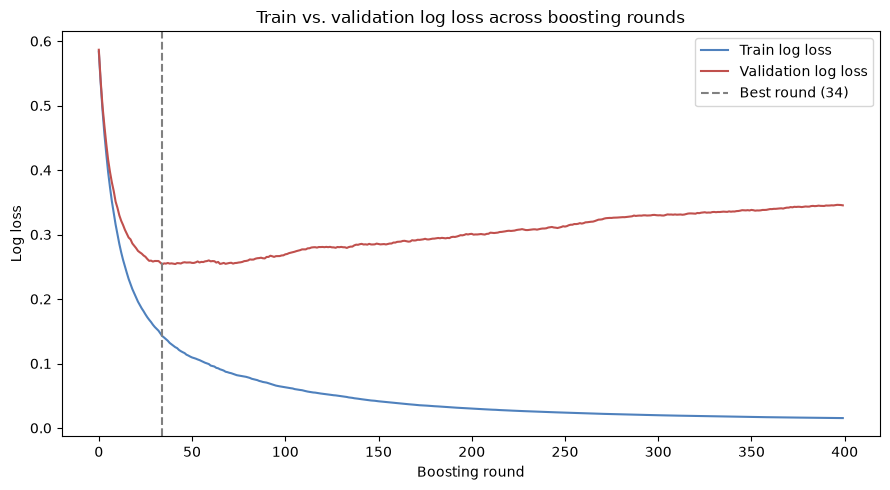

Validation log loss is minimized at round 34: 0.2537
By round 399, validation log loss has drifted to 0.3453
...while training log loss kept falling to 0.0154


In [3]:
curve_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)
curve_model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False)

results = curve_model.evals_result()
train_logloss = results["validation_0"]["logloss"]
val_logloss = results["validation_1"]["logloss"]
best_round = int(np.argmin(val_logloss))

plt.figure(figsize=(9, 5))
plt.plot(train_logloss, label="Train log loss", color="#4f81bd")
plt.plot(val_logloss, label="Validation log loss", color="#c0504d")
plt.axvline(best_round, color="gray", linestyle="--", label=f"Best round ({best_round})")
plt.xlabel("Boosting round")
plt.ylabel("Log loss")
plt.title("Train vs. validation log loss across boosting rounds")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Validation log loss is minimized at round {best_round}: {val_logloss[best_round]:.4f}")
print(f"By round {len(val_logloss)-1}, validation log loss has drifted to {val_logloss[-1]:.4f}")
print(f"...while training log loss kept falling to {train_logloss[-1]:.4f}")

Training log loss keeps decreasing (the model keeps finding ways to fit the training set
better), but validation log loss bottoms out and then flattens or worsens past the marked
round. That marked round is exactly the kind of point `early_stopping_rounds` is built to
detect automatically -- training stops once validation performance hasn't improved for a
specified number of consecutive rounds, instead of us eyeballing a plot.

### The concrete regularization knobs

| Parameter | What it controls | Effect of increasing it |
|---|---|---|
| `max_depth` | Maximum depth of each individual tree | Deeper trees fit more complex patterns per round -- and overfit faster |
| `min_child_weight` | Minimum sum of Hessian ($H$) required in a child node to allow a split | Higher values force splits to only happen on nodes with enough "statistical weight," making the tree more conservative |
| `subsample` | Fraction of training *rows* sampled (without replacement) per round | Injects randomness similar in spirit to Random Forest's bagging, reducing overfitting |
| `colsample_bytree` | Fraction of *features* sampled per tree | Same idea applied to columns -- prevents any one feature from being leaned on too heavily every round |
| `learning_rate` (`eta`) | Shrinkage applied to each round's contribution | Lower values need more rounds but generalize better, as discussed in section 2 |
| `early_stopping_rounds` | Rounds to wait for validation improvement before halting | Directly implements "stop at the dashed line above" automatically |

We revisit several of these with concrete before/after numbers in section 8.

## 6. Why XGBoost is still a "need of the hour" tool

It would be easy to assume a 2014-era algorithm has been superseded by now. It hasn't, and
here's why it's worth knowing cold in 2026:

- **Competition dominance.** Through the mid-to-late 2010s, XGBoost (and its close cousins
  LightGBM and CatBoost) won or placed in the overwhelming majority of Kaggle-style tabular
  data science competitions. Its introduction in 2014 was a genuine inflection point in
  applied ML -- "just try XGBoost" became close to a standing joke because it kept winning.
- **Speed.** XGBoost popularized **histogram-based split finding** (bucket continuous features
  into a fixed number of bins before searching for splits, rather than sorting every unique
  value), plus parallelized and distributed training across cores and machines. This made
  gradient boosting practical on datasets far larger than earlier implementations could
  handle in reasonable time.
- **Most enterprise data is still tabular.** Rows and columns in a database, a spreadsheet, a
  data warehouse -- not images, not free text, not audio. Deep learning's biggest wins are
  concentrated in unstructured data; for structured/tabular problems, gradient-boosted trees
  remain, by a wide and repeatedly-benchmarked margin, the strongest general-purpose
  off-the-shelf family of models.
- **Real production usage today**, not just competitions: **credit scoring** (deciding loan
  risk from applicant and bureau features), **ad click-through-rate prediction** (ranking
  which ad a user is likeliest to click, at massive scale and low latency), and **search/
  recommendation ranking systems** (re-ranking candidate results using dozens of tabular
  signals) are all domains where gradient-boosted trees are a standard production choice,
  often alongside or ahead of deep learning approaches.

The plain takeaway: if you work with tabular business data -- which most working data
scientists do, most of the time -- XGBoost is not a nostalgic relic. It is very often still
the right first model to reach for.

## 7. Training and evaluating the final model

Using the train-vs-validation curve from section 5, we now train a final model:

1. Fit with early stopping on the `(X_tr, y_tr)` / `(X_val, y_val)` split to find the
   validation-optimal number of rounds.
2. Refit on the **full** training set (`X_train_full`, i.e. `X_tr` + `X_val` combined) using
   that fixed number of rounds, so the final model gets to learn from every training row we
   have.
3. Evaluate **once**, on the held-out `X_test` / `y_test` -- which neither step above ever
   saw.

In [4]:
es_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    eval_metric="logloss",
    early_stopping_rounds=25,
    random_state=RANDOM_STATE,
)
es_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
best_n_estimators = es_model.best_iteration + 1
print(f"Early stopping selected {best_n_estimators} rounds (out of 400 allowed).")

final_model = xgb.XGBClassifier(
    n_estimators=best_n_estimators,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    random_state=RANDOM_STATE,
)
final_model.fit(X_train_full, y_train_full)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "log_loss": log_loss(y_test, y_proba),
}
pd.Series(metrics).round(4)

Early stopping selected 44 rounds (out of 400 allowed).


accuracy     0.8766
precision    0.8302
recall       0.8148
f1           0.8224
roc_auc      0.9524
log_loss     0.2774
dtype: float64

**Reading these numbers:**

- **Accuracy** -- overall fraction correct; can be misleading alone given the ~65/35 class
  imbalance, which is why we report the rest too.
- **Precision** -- of the patients we predicted diabetic, what fraction actually are; matters
  when false positives (unnecessary follow-up testing) are costly.
- **Recall** -- of the patients who actually are diabetic, what fraction we caught; matters
  when false negatives (missed diagnoses) are the costlier error -- often the more clinically
  important number for a screening tool.
- **F1** -- the harmonic mean of precision and recall, a single balance-point summary.
- **ROC-AUC** -- how well the model ranks positive cases above negative cases across every
  possible decision threshold, independent of any one chosen cutoff.
- **Log loss** -- the same objective XGBoost is internally minimizing; unlike accuracy, it
  penalizes *confidently wrong* predictions much more heavily than *hesitant* wrong ones.

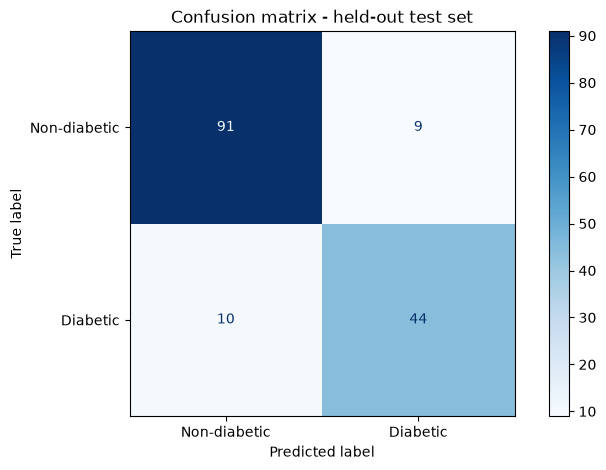

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-diabetic", "Diabetic"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix - held-out test set")
plt.show()

### Feature importance: three different lenses

XGBoost reports (at least) three distinct notions of "importance," and they can disagree with
each other -- each is counting something genuinely different:

- **`weight`** -- how many times a feature was used to split, across every tree in the
  ensemble. A feature used in many small, frequent splits scores high here, regardless of how
  much each split actually improved the model.
- **`gain`** -- the total improvement in the training objective (recall the `Gain` formula
  from section 3) contributed by every split on that feature, summed across all trees. This
  is usually the most informative single number: it answers "how much did this feature
  actually help minimize loss," not just "how often was it used."
- **`cover`** -- the average number of training examples affected by splits on that feature
  (weighted by the Hessian $H$ at each split). A feature with high cover is influencing
  decisions for a large, "confident" portion of the data, even if it isn't split on as
  frequently as a `weight`-heavy feature.

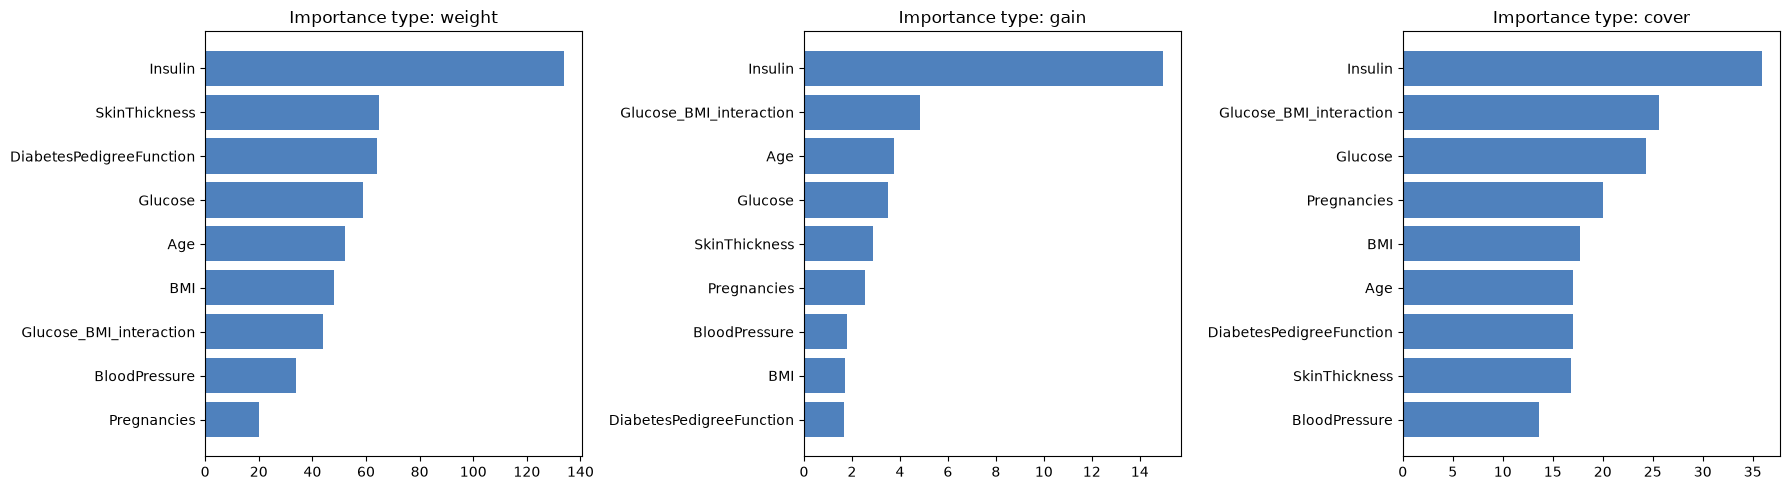

In [6]:
booster = final_model.get_booster()
importance_types = ["weight", "gain", "cover"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, imp_type in zip(axes, importance_types):
    scores = booster.get_score(importance_type=imp_type)
    scores = dict(sorted(scores.items(), key=lambda kv: kv[1]))
    ax.barh(list(scores.keys()), list(scores.values()), color="#4f81bd")
    ax.set_title(f"Importance type: {imp_type}")

plt.tight_layout()
plt.show()

`Glucose` and the engineered `Glucose_BMI_interaction` feature tend to rank highly across
all three views -- consistent with the EDA notebook, where `Glucose` was the single feature
most correlated with `Outcome`. Where the three views disagree is informative too: a feature
that is used often (`weight`) but doesn't rank as highly by `gain` is being split on
frequently without contributing much actual loss reduction per split -- a useful nuance a
single importance number would hide.

### Visualizing one tree from the ensemble

`final_model` was trained with `max_depth=4`, so unlike a Random Forest's fully-grown trees,
**every single tree in this ensemble is already shallow enough to read directly** — no
truncation needed. `xgboost.plot_tree` needs the external Graphviz binary, which isn't part
of this workshop's environment, so we draw the tree ourselves straight from
`booster.trees_to_dataframe()` — a plain pandas table listing every node, its split, and its
two children, for every tree in the ensemble.

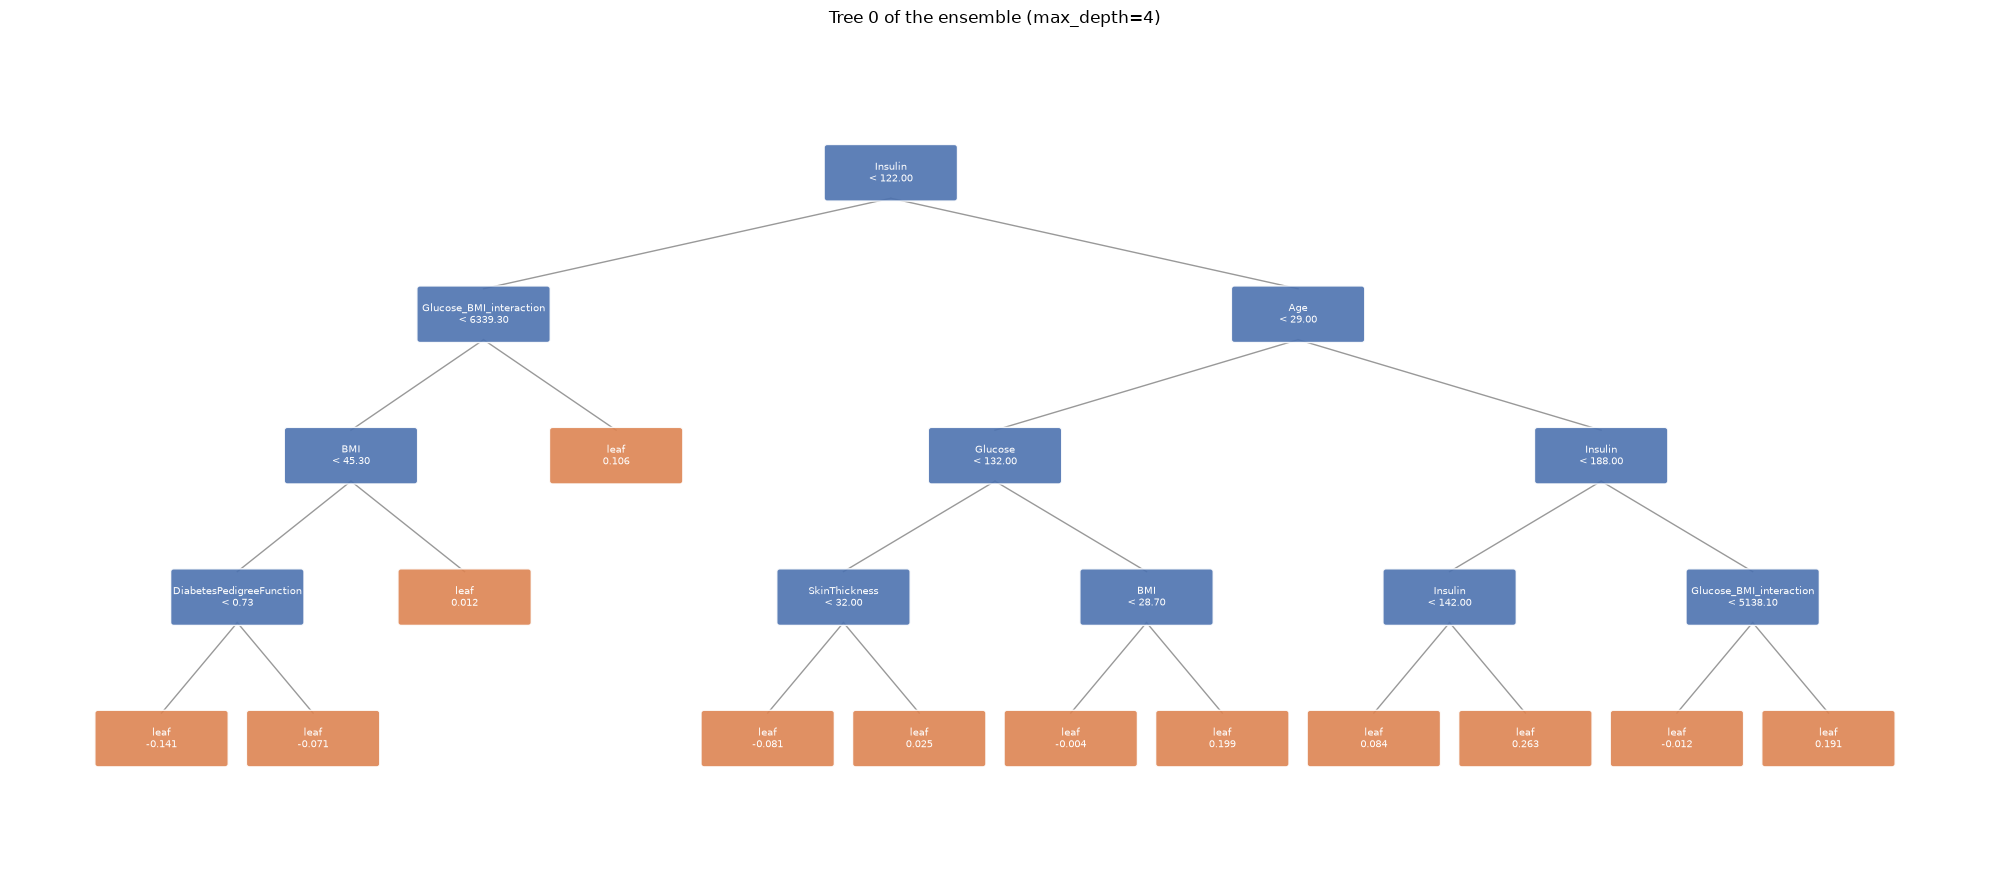

In [7]:
from matplotlib.patches import FancyBboxPatch


def plot_xgb_tree(booster, tree_index, ax, title):
    """Draw one boosted tree (depth <= max_depth) directly from trees_to_dataframe()."""
    df = booster.trees_to_dataframe()
    tree_df = df[df["Tree"] == tree_index].set_index("ID")
    root_id = tree_df.index[0]

    # BFS from the root to get each node's depth
    depth = {root_id: 0}
    order = [root_id]
    for nid in order:
        row = tree_df.loc[nid]
        if row["Feature"] != "Leaf":
            for child in [row["Yes"], row["No"]]:
                depth[child] = depth[nid] + 1
                order.append(child)

    # A simple recursive layout: leaves get sequential x positions, parents sit
    # above the midpoint of their children
    x_pos, counter = {}, [0]

    def assign_x(nid):
        row = tree_df.loc[nid]
        if row["Feature"] == "Leaf":
            x_pos[nid] = counter[0]
            counter[0] += 1
            return x_pos[nid]
        x_pos[nid] = (assign_x(row["Yes"]) + assign_x(row["No"])) / 2
        return x_pos[nid]

    assign_x(root_id)
    max_depth_val = max(depth.values())

    for nid in order:
        row = tree_df.loc[nid]
        x, y = x_pos[nid], -depth[nid]
        is_leaf = row["Feature"] == "Leaf"
        label = f"leaf\n{row['Gain']:.3f}" if is_leaf else f"{row['Feature']}\n< {row['Split']:.2f}"
        color = "#DD8452" if is_leaf else "#4C72B0"
        ax.add_patch(FancyBboxPatch((x - 0.42, y - 0.18), 0.84, 0.36, boxstyle="round,pad=0.02",
                                     facecolor=color, edgecolor="white", alpha=0.9))
        ax.text(x, y, label, ha="center", va="center", fontsize=7, color="white")
        if not is_leaf:
            for child_id in [row["Yes"], row["No"]]:
                cx, cy = x_pos[child_id], -depth[child_id]
                ax.plot([x, cx], [y - 0.18, cy + 0.18], color="#999999", linewidth=1, zorder=0)

    ax.set_xlim(-1, counter[0])
    ax.set_ylim(-max_depth_val - 1, 1)
    ax.axis("off")
    ax.set_title(title)


fig, ax = plt.subplots(figsize=(20, 9))
plot_xgb_tree(booster, tree_index=0, ax=ax, title="Tree 0 of the ensemble (max_depth=4)")
plt.tight_layout()
plt.show()

**Reading this tree:** the blue boxes are split nodes (feature and threshold); the orange
boxes are leaves, each labeled with its **leaf weight** — exactly the $w_j^*$ derived in
Section 3, not a class probability. A single tree's leaf weight is this one round's
*contribution* to the running total $F_m(x)$; the final predicted probability only appears
after summing every tree's leaf weight (scaled by $\eta$) across all `best_n_estimators`
rounds and passing that sum through the sigmoid — which is exactly why some leaves above show
a small negative weight (this tree is voting slightly *toward* "non-diabetic" for those
patients) even though the model overall is quite accurate: each tree only ever nudges the
running prediction a little.

## 8. Model hyperparameters, as a tuning reference

We've already met every one of these conceptually in sections 2, 3, and 5. Here they are
again, gathered as a single reference, each tied back to the specific piece of theory it
controls:

| Parameter | Ties back to | What it does |
|---|---|---|
| `n_estimators` | Section 2 ($M$, the number of rounds) | Total number of boosting rounds (trees) added. More rounds = more capacity, and more overfitting risk if unchecked. |
| `learning_rate` (`eta`) | Section 2 ($\eta$ in $F_m = F_{m-1} + \eta h_m$) | Shrinks every round's contribution. Smaller values need more rounds to reach the same fit, but generalize better -- the classic rounds-vs-shrinkage trade-off. |
| `max_depth` | Section 5 | Maximum depth of each tree grown per round. Controls how complex a single round's correction can be -- deeper trees fit faster but overfit faster too. |
| `min_child_weight` | Section 3 (the $H_L$, $H_R$ terms in the `Gain` formula) | Minimum sum of Hessian required in a child before a split is allowed. Directly reads off the same $H$ that appears in the gain formula -- raising it means a split needs more "statistical weight" behind it to be permitted, making splits more conservative. |
| `subsample` | Section 5 | Fraction of training rows randomly sampled (without replacement) for each round. Injects row-level stochasticity, similar in spirit to Random Forest's bootstrap bagging, which reduces overfitting. |
| `colsample_bytree` | Section 5 | Fraction of features randomly sampled for each tree. Column-level analogue of `subsample`, similarly reducing overfitting by preventing any single feature from being leaned on every round. |
| `gamma` | Section 3 (the $-\gamma$ term in the `Gain` formula) | The minimum-gain threshold a split must clear to be made at all. Raising `gamma` directly prunes more splits -- a candidate split whose computed `Gain` doesn't exceed `gamma` is simply not made, so the tree stays shallower and simpler. |
| `reg_lambda` | Section 3 ($\lambda$ in $\Omega(f) = \gamma T + \tfrac{1}{2}\lambda\sum_j w_j^2$) | L2 regularization on leaf weights $w_j$. Larger `reg_lambda` shrinks leaf output values toward zero, damping how confidently any single leaf can vote. |
| `reg_alpha` | Section 3 (L1 analogue of $\Omega(f)$) | L1 regularization on leaf weights. Like `reg_lambda` but can push some leaf weights to exactly zero, giving a sparser, more selective set of active leaves. |
| `early_stopping_rounds` | Section 5 | Number of rounds to tolerate no validation improvement before halting training -- the automated version of the dashed line in the log-loss plot above. |

### Seeing a knob move the needle: a `learning_rate` sweep

Rather than just describing the effect, let's measure it. We fix `n_estimators` and sweep
`learning_rate`, recording validation log loss and ROC-AUC for each value -- reusing the same
`(X_tr, y_tr)` / `(X_val, y_val)` split as the overfitting curve in section 5.

In [8]:
learning_rates = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
sweep_rows = []

for lr in learning_rates:
    m = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=lr,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
    )
    m.fit(X_tr, y_tr)
    proba = m.predict_proba(X_val)[:, 1]
    sweep_rows.append({
        "learning_rate": lr,
        "val_log_loss": log_loss(y_val, proba),
        "val_roc_auc": roc_auc_score(y_val, proba),
    })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

,learning_rate,val_log_loss,val_roc_auc
0,0.01,0.253386,0.966570
1,0.03,0.254759,0.963081
2,0.05,0.299724,0.954942
3,0.10,0.325446,0.956105
4,0.20,0.342838,0.953779
5,0.30,0.368754,0.954070
6,0.50,0.397790,0.955523


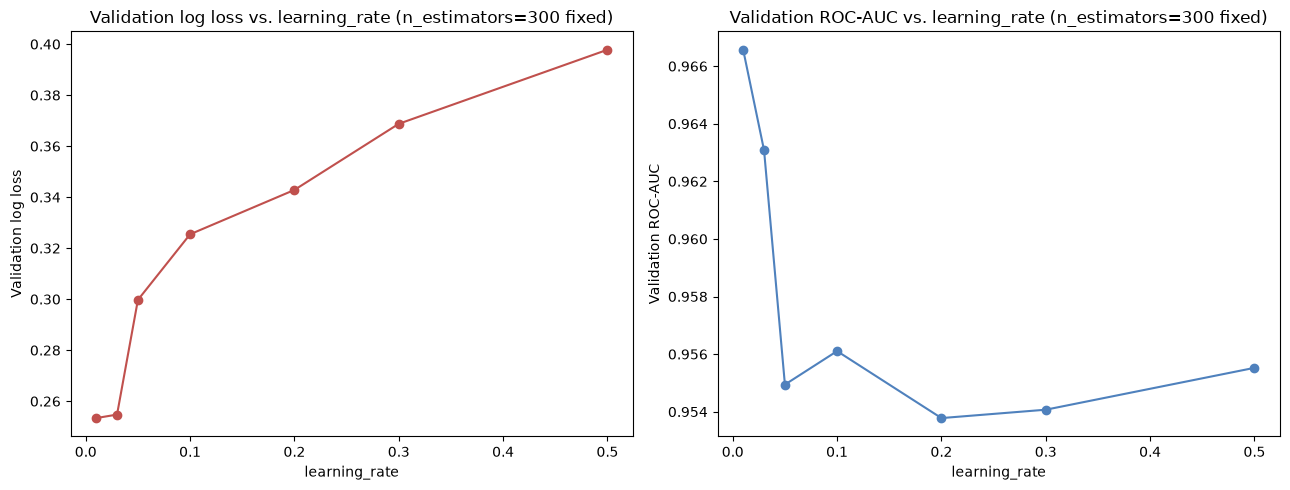

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(sweep_df["learning_rate"], sweep_df["val_log_loss"], marker="o", color="#c0504d")
axes[0].set_xlabel("learning_rate")
axes[0].set_ylabel("Validation log loss")
axes[0].set_title("Validation log loss vs. learning_rate (n_estimators=300 fixed)")

axes[1].plot(sweep_df["learning_rate"], sweep_df["val_roc_auc"], marker="o", color="#4f81bd")
axes[1].set_xlabel("learning_rate")
axes[1].set_ylabel("Validation ROC-AUC")
axes[1].set_title("Validation ROC-AUC vs. learning_rate (n_estimators=300 fixed)")

plt.tight_layout()
plt.show()

With `n_estimators` held fixed at 300, validation log loss climbs fairly steadily as
`learning_rate` increases -- 300 rounds is generous enough that even the smallest rate
(`0.01`) has room to fully converge, so here we are looking almost entirely at the
**overshooting** side of the trade-off from section 2: larger steps per round push the
ensemble past the validation-optimal fit faster, and it starts absorbing training noise
sooner. ROC-AUC tells a gentler version of the same story -- it dips as `learning_rate`
grows and never fully recovers to its low-`learning_rate` level within this sweep.

This is a useful, honest counter-example to "just pick something in the middle": the correct
takeaway is not that intermediate values are always best, but that **`learning_rate` and
`n_estimators` are coupled** -- a very small `learning_rate` looks great here specifically
*because* we generously fixed `n_estimators=300`. Cut the round budget down to, say, 30, and
the smallest learning rates would instead look *underfit* (too few, too-small steps to reach
a good fit at all), reproducing the classic U-shaped trade-off from section 2. Whenever you
tune `learning_rate` in practice, tune it jointly with `n_estimators` (typically via
`early_stopping_rounds`, exactly as in section 7) rather than in isolation.

## 9. The wider landscape: pluggable loss functions

Everything above used **log loss** (binary cross-entropy) as the loss being minimized:

$$\text{log loss} = -\big[y \log(\hat p) + (1-y)\log(1-\hat p)\big]$$

This is the natural choice for binary classification because its gradient and Hessian have
clean closed forms and it directly optimizes probability calibration. But it is far from the
only loss gradient boosting has used historically. **AdaBoost**, one of the earliest boosting
algorithms (pre-dating gradient boosting's general formulation), classically minimizes the
**exponential loss**:

$$\text{exponential loss} = e^{-y \cdot F(x)}, \qquad y \in \{-1, +1\}$$

Exponential loss penalizes confidently wrong predictions even more aggressively than log loss
does (the penalty grows exponentially rather than logarithmically), which historically made
AdaBoost more sensitive to outliers and mislabeled examples than log-loss-based boosting.

**The general point that matters most:** gradient boosting, as a framework, is
**loss-agnostic**. As long as a loss function is **twice-differentiable** (so that the
gradient $g_i$ and Hessian $h_i$ from section 3 exist), you can plug it directly into
XGBoost's split-finding machinery -- swap in mean-squared error for regression, quantile loss
for prediction intervals, ranking losses for search/recommendation systems, or a custom loss
tailored to a specific business cost asymmetry. The `Gain` formula and the overall algorithm
don't change; only $g_i$ and $h_i$ do.

> **Contrast with Random Forest.** Random Forest has no equivalent notion of a swappable
> loss -- its splitting rule is fixed to Gini impurity (or entropy) by construction, because
> that rule comes from the CART splitting criterion, not from differentiating an arbitrary
> loss. This pluggability is a structural advantage gradient boosting has that bagging-based
> ensembles like Random Forest simply do not.

## Summary

- Random Forest reduces variance by averaging independent trees; gradient boosting (and
  XGBoost) reduces bias by sequentially fitting each new tree to the current pseudo-residuals,
  scaled by a learning rate $\eta$.
- XGBoost replaces Gini/entropy splitting with a regularized, second-order (gradient +
  Hessian) `Gain` formula, baking $\gamma$ (split complexity penalty) and $\lambda$ (leaf
  weight L2 penalty) directly into the split criterion.
- XGBoost can route missing values natively via a learned "default direction" -- but knowing
  *why* a value is missing (our sentinel-zero case) usually still justifies imputing it
  thoughtfully rather than leaning on that shortcut.
- Boosting overfits by over-fitting training noise across too many rounds or too high a
  learning rate; the train-vs-validation log-loss curve and `early_stopping_rounds` are the
  direct countermeasures, alongside `max_depth`, `min_child_weight`, `subsample`, and
  `colsample_bytree`.
- On the held-out test set, the final model achieved the metrics reported in section 7 above.
- XGBoost remains a first-choice tool for tabular business problems today -- credit scoring,
  ad click-through-rate prediction, and ranking are all live production use cases, not just
  competition trivia.
- Gradient boosting's loss function is swappable (log loss, exponential loss, and beyond, as
  long as it's twice-differentiable); Random Forest's Gini-based split rule is not -- a
  structural difference worth remembering when choosing between the two families.